# 🫀 Notebook 1 — Preprocesamiento de Datos
## Identificación de Fenotipos de Pacientes con Insuficiencia Cardíaca
**Proyecto Curso I — Especialización Machine Learning Engineering**  
Ramos Miranda, Jaime

---
Este notebook cubre la carga, exploración, limpieza y estandarización del dataset *Heart Failure Clinical Records*,
dejando los datos listos para el análisis de conglomerados.

## 1. Librerías

In [6]:
!pip install matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.stats import chi2

import warnings
warnings.filterwarnings("ignore")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Carga y exploración inicial

In [23]:
base = pd.read_csv("../data/heart_failure_clinical_records_dataset1.csv")
print("=== Dimensiones ===")
print(base.shape)

print("\n=== Primeras filas ===")
base.head()

=== Dimensiones ===
(299, 13)

=== Primeras filas ===


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [11]:
print("=== Resumen estadístico ===")
base.describe()

=== Resumen estadístico ===


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [12]:
print("=== Tipos de datos ===")
print(base.dtypes)

print("\n=== Distribución de DEATH_EVENT ===")
print(base["DEATH_EVENT"].value_counts())
print(f"Tasa de mortalidad: {base['DEATH_EVENT'].mean()*100:.1f}%")

=== Tipos de datos ===
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

=== Distribución de DEATH_EVENT ===
DEATH_EVENT
0    203
1     96
Name: count, dtype: int64
Tasa de mortalidad: 32.1%


## 3. Separación del target

`DEATH_EVENT` **no se usa en el clustering**. Se separa aquí y se reserva para validación clínica externa en el notebook 2.

In [13]:
target_original = base["DEATH_EVENT"].copy()
Datos0 = base.drop(columns=["DEATH_EVENT"]).copy()

print(f"Variables para clustering: {list(Datos0.columns)}")
print(f"Shape de Datos0: {Datos0.shape}")

Variables para clustering: ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time']
Shape de Datos0: (299, 12)


## 4. Verificación de valores nulos

In [14]:
print("=== Valores nulos por columna ===")
print(Datos0.isna().sum())
print(f"\nTotal de valores nulos: {Datos0.isna().sum().sum()}")

# Eliminar filas con NA por si las hubiera
Datos0 = Datos0.dropna()
target_original = target_original[Datos0.index]
print(f"\nFilas tras eliminar nulos: {len(Datos0)}")

=== Valores nulos por columna ===
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
dtype: int64

Total de valores nulos: 0

Filas tras eliminar nulos: 299


## 5. Análisis exploratorio visual

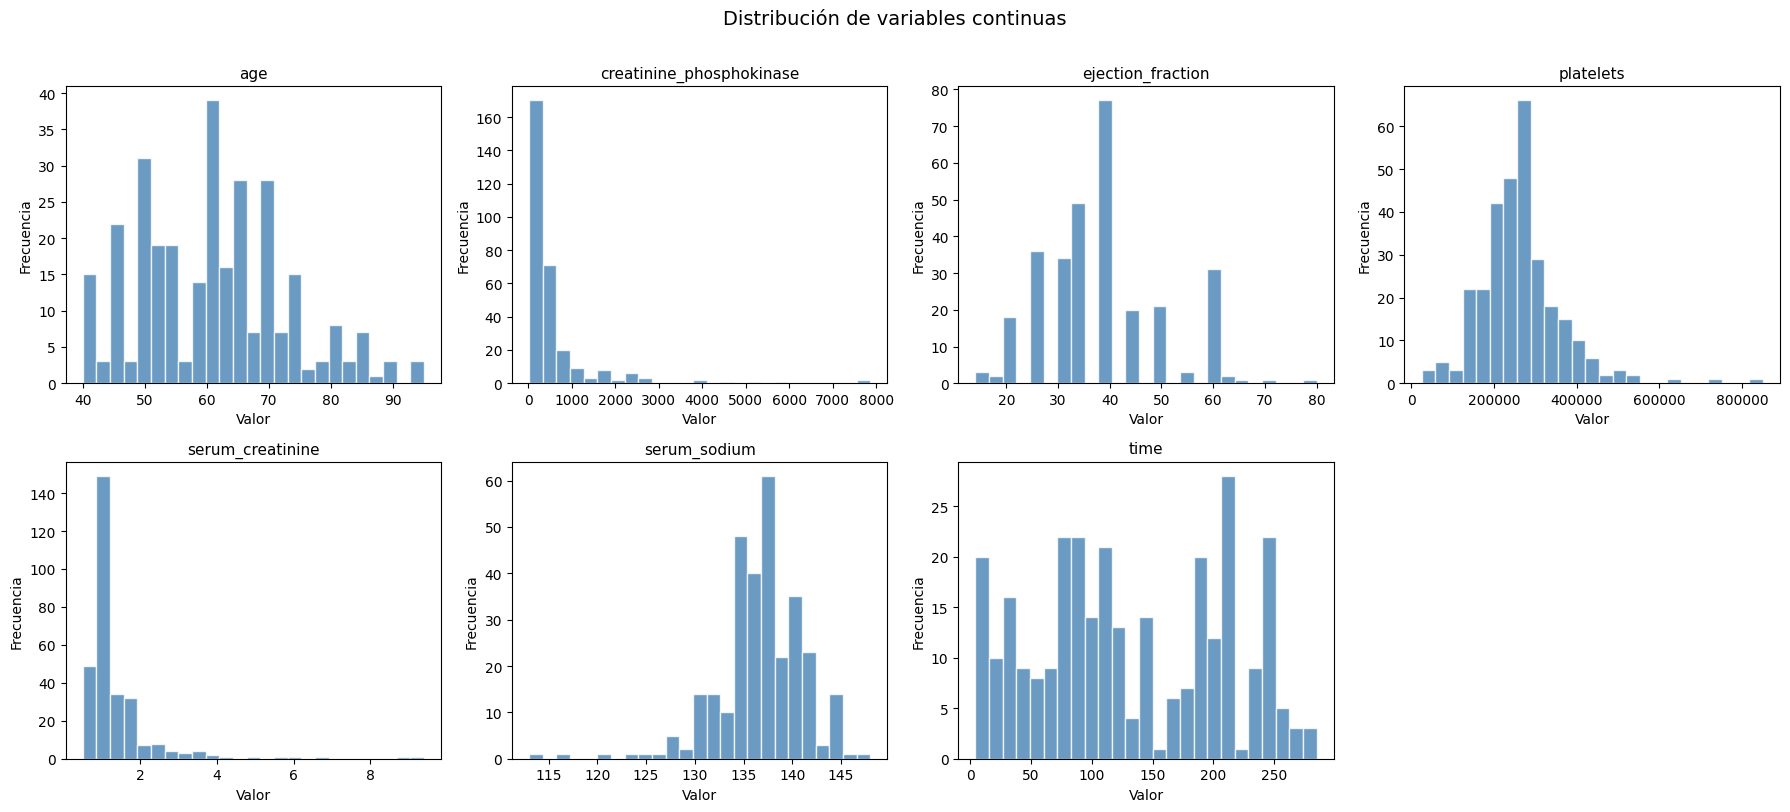

In [15]:
# Distribuciones de variables continuas
cols_continuas = ["age", "creatinine_phosphokinase", "ejection_fraction",
                  "platelets", "serum_creatinine", "serum_sodium", "time"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cols_continuas):
    axes[i].hist(base[col], bins=25, color="steelblue", edgecolor="white", alpha=0.8)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("Valor")
    axes[i].set_ylabel("Frecuencia")

axes[-1].set_visible(False)
fig.suptitle("Distribución de variables continuas", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../artifacts/distribucion_variables.png", dpi=150, bbox_inches="tight")
plt.show()

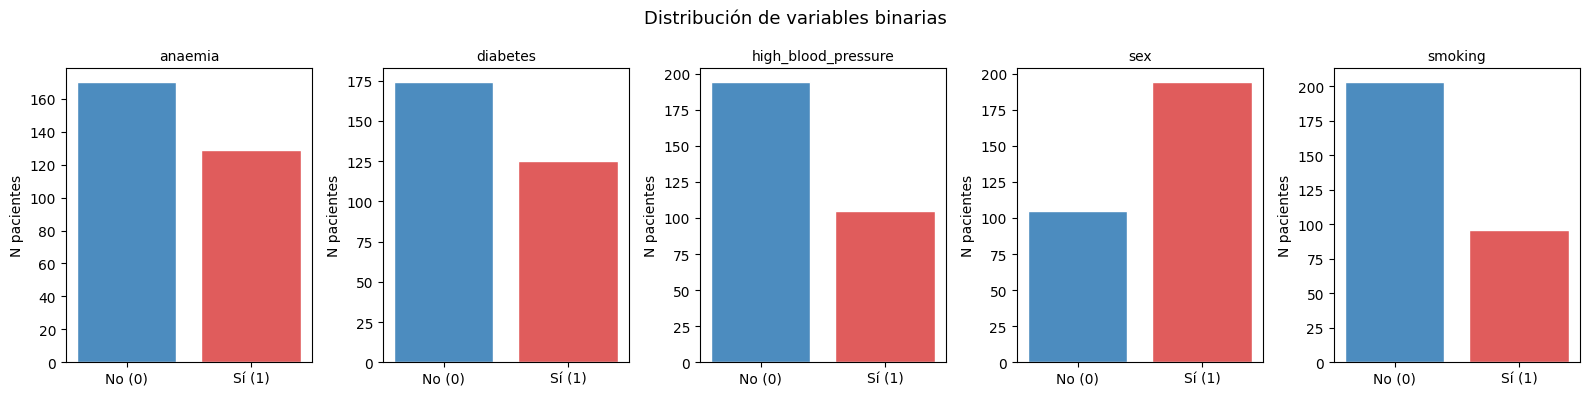

In [16]:
# Variables binarias
cols_binarias = ["anaemia", "diabetes", "high_blood_pressure", "sex", "smoking"]

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for i, col in enumerate(cols_binarias):
    counts = base[col].value_counts()
    axes[i].bar(["No (0)", "Sí (1)"], [counts.get(0,0), counts.get(1,0)],
                color=["#4C8CBF", "#E05C5C"], edgecolor="white")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel("N pacientes")

fig.suptitle("Distribución de variables binarias", fontsize=13)
plt.tight_layout()
plt.savefig("../artifacts/distribucion_binarias.png", dpi=150, bbox_inches="tight")
plt.show()

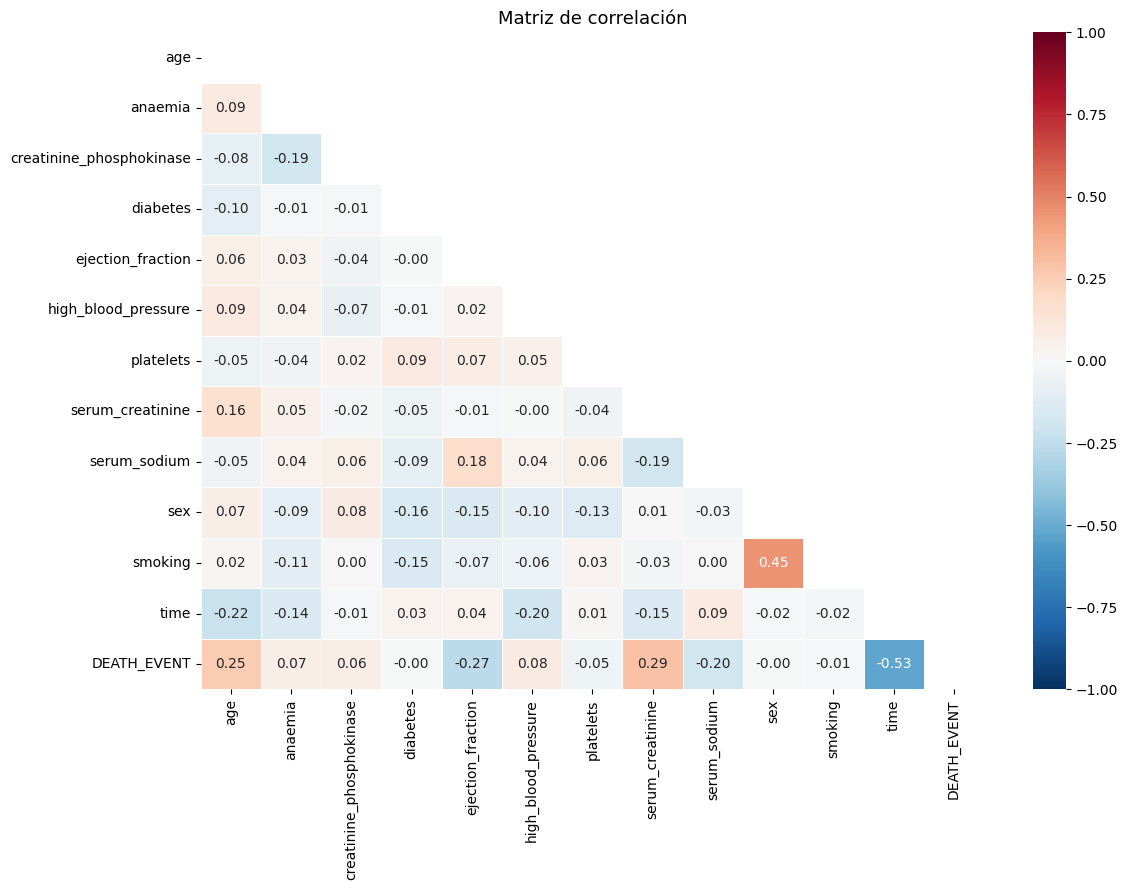

In [17]:
# Mapa de correlaciones
plt.figure(figsize=(12, 9))
corr = base.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, linewidths=0.5, vmin=-1, vmax=1)
plt.title("Matriz de correlación", fontsize=13)
plt.tight_layout()
plt.savefig("../artifacts/correlaciones.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Estandarización

Las variables tienen escalas muy distintas (ej: `platelets` en cientos de miles vs `age` en decenas). La estandarización es **indispensable** para que el clustering no esté dominado por variables de mayor magnitud.

In [18]:
scaler = StandardScaler()
Datos_array = scaler.fit_transform(Datos0)
Datos = pd.DataFrame(Datos_array, columns=Datos0.columns, index=Datos0.index)

print("=== Estadísticas tras estandarización (deben ser ~0 media, ~1 std) ===")
print(Datos.describe().loc[["mean", "std"]].round(3))

=== Estadísticas tras estandarización (deben ser ~0 media, ~1 std) ===
        age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
mean  0.000    0.000                     0.000     0.000             -0.000   
std   1.002    1.002                     1.002     1.002              1.002   

      high_blood_pressure  platelets  serum_creatinine  serum_sodium    sex  \
mean                0.000      0.000             0.000        -0.000 -0.000   
std                 1.002      1.002             1.002         1.002  1.002   

      smoking   time  
mean   -0.000 -0.000  
std     1.002  1.002  


## 7. Detección de outliers multivariantes (Distancia de Mahalanobis)

Se usa la distancia de Mahalanobis con umbral chi-cuadrado al 97.5% para detectar observaciones atípicas en el espacio multivariante — equivalente al método `MVN::mvn` con `multivariateOutlierMethod='quan'` en R.

In [19]:
def mahalanobis_outliers(df, threshold_quantile=0.975):
    """
    Detecta outliers multivariados usando distancia de Mahalanobis.

    Parameters
    ----------
    df : pd.DataFrame
        Datos estandarizados.
    threshold_quantile : float
        Cuantil chi-cuadrado para definir el umbral (default: 0.975).

    Returns
    -------
    outliers : np.ndarray
        Índices posicionales de los outliers detectados.
    dist_sq : np.ndarray
        Distancias de Mahalanobis al cuadrado por observación.
    """
    cov = np.cov(df.T)
    cov_inv = np.linalg.pinv(cov)
    mean = df.mean(axis=0)
    diff = df - mean
    dist_sq = np.array([d @ cov_inv @ d for d in diff.values])
    cutoff = chi2.ppf(threshold_quantile, df=df.shape[1])
    outliers = np.where(dist_sq > cutoff)[0]
    return outliers, dist_sq

outliers_idx, mah_dist = mahalanobis_outliers(Datos)
print(f"Outliers detectados (índices posicionales): {outliers_idx}")
print(f"Total outliers: {len(outliers_idx)}")
print(f"Pacientes antes: {len(Datos)} → después: {len(Datos) - len(outliers_idx)}")

Outliers detectados (índices posicionales): [  1   4   9  19  28  52  60  72 103 105 109 131 134 199 217 296]
Total outliers: 16
Pacientes antes: 299 → después: 283


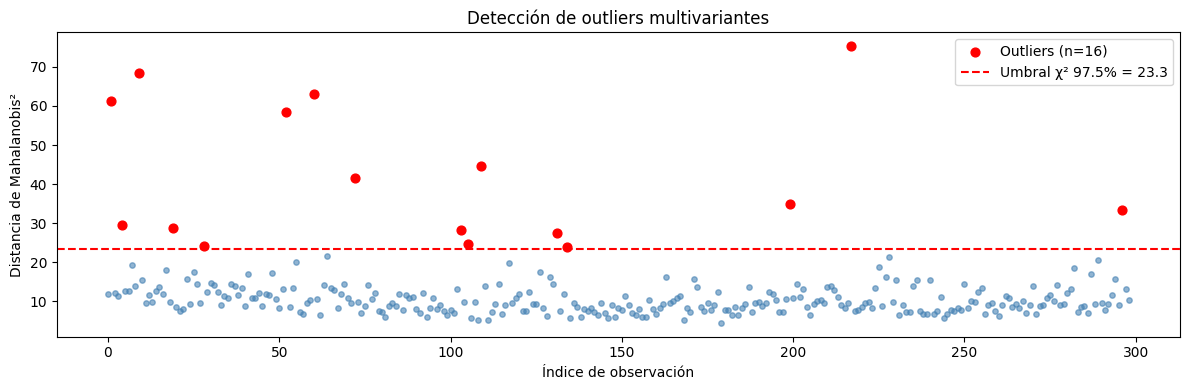

In [20]:
# Visualizar distancias de Mahalanobis
cutoff_val = chi2.ppf(0.975, df=Datos.shape[1])

plt.figure(figsize=(12, 4))
plt.scatter(range(len(mah_dist)), mah_dist, s=15, color="steelblue", alpha=0.6)
plt.scatter(outliers_idx, mah_dist[outliers_idx], s=40, color="red",
            label=f"Outliers (n={len(outliers_idx)})", zorder=5)
plt.axhline(cutoff_val, color="red", linestyle="--", label=f"Umbral χ² 97.5% = {cutoff_val:.1f}")
plt.xlabel("Índice de observación")
plt.ylabel("Distancia de Mahalanobis²")
plt.title("Detección de outliers multivariantes")
plt.legend()
plt.tight_layout()
plt.savefig("../artifacts/outliers_mahalanobis.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
# Eliminar outliers
Datos_clean = Datos.drop(Datos.index[outliers_idx]).reset_index(drop=True)
Datos0_clean = Datos0.drop(Datos0.index[outliers_idx]).reset_index(drop=True)
target_clean = target_original.drop(target_original.index[outliers_idx]).reset_index(drop=True)

print(f"Dataset final para clustering: {Datos_clean.shape[0]} pacientes × {Datos_clean.shape[1]} variables")

Dataset final para clustering: 283 pacientes × 12 variables


## 8. Guardar datos preprocesados

In [22]:
# Guardar datos estandarizados y limpios para usar en el notebook 2
Datos_clean.to_csv("../data/datos_estandarizados.csv", index=False)
Datos0_clean.to_csv("../data/datos_originales_limpios.csv", index=False)
target_clean.to_csv("../data/target.csv", index=False, header=True)

print("Archivos guardados en /data:")
print("  - datos_estandarizados.csv")
print("  - datos_originales_limpios.csv")
print("  - target.csv")

Archivos guardados en /data:
  - datos_estandarizados.csv
  - datos_originales_limpios.csv
  - target.csv


---
## ✅ Resumen del preprocesamiento

| Paso | Resultado |
|---|---|
| Pacientes originales | 299 |
| Valores nulos | 0 |
| Outliers eliminados (Mahalanobis) | 16 |
| **Pacientes finales** | **283** |
| Variables para clustering | 12 (sin DEATH_EVENT) |
| Estandarización | StandardScaler (media=0, std=1) |

➡️ Continuar en `02_clustering_y_analisis.ipynb`